# Predicting XLogP for Anticancer Drug Candidates from SMILES

**Goal:** given only a SMILES string for an unknown molecule, predict its XLogP
(PubChem's computed octanol-water partition coefficient).

**Data:** `PubChem_compound_anticancer.csv` — 216 anticancer compounds, 191 of
which have a real, PubChem-computed XLogP value. We train directly on these
(no proxy dataset needed, unlike the earlier solubility notebook, since your
own file already has real target values).

**Note on sample size:** 191 labeled compounds is small for a neural network,
which tends to overfit at this scale. This notebook uses **Random Forest** as
the primary model (much more robust for small tabular data) and includes an
optional PyTorch NN for comparison, so you can see both and judge which
generalizes better.

## 1. Install & import dependencies

In [2]:
!pip install rdkit -q

import glob
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

print("Imports OK")


Imports OK


## 2. Load your anticancer CSV\n\nLooks for the file directly in Colab's local storage (case-insensitive).

In [3]:
candidates = [f for f in glob.glob("*") if f.lower() == "pubchem_compound_anticancer.csv"]

if not candidates:
    raise FileNotFoundError(
        "Could not find 'PubChem_compound_anticancer.csv' in the current directory. "
        "Check the folder icon on the left sidebar, or upload it with:\n"
        "    from google.colab import files\n"
        "    uploaded = files.upload()"
    )

anticancer_path = Path(candidates[0])
print("Using file:", anticancer_path)

df_raw = pd.read_csv(anticancer_path)
print("Rows:", len(df_raw))
print("Columns:", list(df_raw.columns))


Using file: PubChem_compound_anticancer.csv
Rows: 216
Columns: ['Compound_CID', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI', 'SMILES', 'InChIKey', 'IUPAC_Name', 'MeSH_Headings', 'Annotation_Content', 'Linked_BioAssays', 'Data_Source', 'Data_Source_Category', 'Tagged_by_PubChem', 'Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'Heavy_Atom_Count', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count', 'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 'Covalent_Unit_Count', 'Isotopic_Atom_Count', 'Total_Atom_Stereo_Count', 'Defined_Atom_Stereo_Count', 'Undefined_Atom_Stereo_Count', 'Total_Bond_Stereo_Count', 'Defined_Bond_Stereo_Count', 'Undefined_Bond_Stereo_Count', 'Linked_PubChem_Literature_Count', 'Linked_PubChem_Patent_Count', 'Linked_PubChem_Patent_Family_Count', 'Annotation_Type_Count', 'Create_Date']


## 3. Prepare target (XLogP) and keep only labeled rows\n\nXLogP is missing for some compounds (PubChem couldn't compute it, e.g. for very complex or poorly-defined structures) — we drop those for training.

In [4]:
df = df_raw[["SMILES", "Name", "XLogP"]].copy()
df = df.dropna(subset=["SMILES", "XLogP"])
df["XLogP"] = pd.to_numeric(df["XLogP"], errors="coerce")
df = df.dropna(subset=["XLogP"])
print(f"Labeled compounds available for training: {len(df)} / {len(df_raw)}")

df["XLogP"].describe()


Labeled compounds available for training: 191 / 216


,XLogP
count,191.000000
mean,4.268586
std,2.353756
min,-3.300000
25%,2.900000
50%,4.200000
75%,5.300000
max,20.200000


### Sanity check for outliers\n\nXLogP values outside roughly -3 to 10 are unusual for drug-like molecules and are worth a visual check — they could be genuine (large lipophilic scaffolds) or a parsing/data issue upstream in PubChem's annotation.

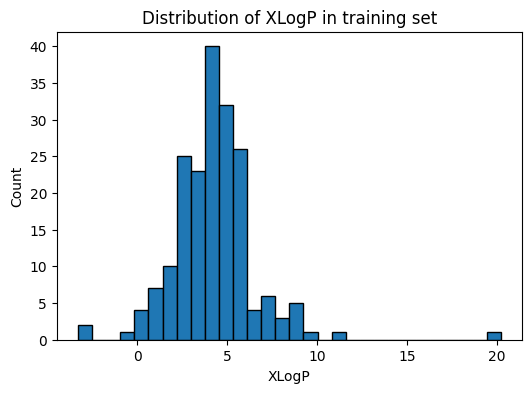

3 compounds with |XLogP| in an unusual range:


,Name,XLogP
39,Anticancer Hydroxytriolein,20.2
66,Anticancer agent 263,-3.3
114,Anticancer agent 33,10.9


In [5]:
plt.figure(figsize=(6,4))
plt.hist(df["XLogP"], bins=30, edgecolor="black")
plt.xlabel("XLogP")
plt.ylabel("Count")
plt.title("Distribution of XLogP in training set")
plt.show()

outliers = df[(df["XLogP"] < -3) | (df["XLogP"] > 10)]
print(f"{len(outliers)} compounds with |XLogP| in an unusual range:")
outliers[["Name", "XLogP"]]


## 4. Compute RDKit descriptors from SMILES\n\nThese are the features the model will actually use — computed fresh from structure, so the exact same function can be applied later to any unknown SMILES you want a prediction for.

In [6]:
FEATURE_NAMES = [
    "MolWt", "MolLogP_Crippen", "TPSA", "NumHDonors", "NumHAcceptors",
    "NumRotatableBonds", "RingCount", "NumAromaticRings",
    "FractionCSP3", "HeavyAtomCount", "NumHeteroatoms",
]

def get_features(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return [
            Descriptors.MolWt(mol),
            Crippen.MolLogP(mol),          # RDKit's own logP estimate - a legitimate, informative feature
            Descriptors.TPSA(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.RingCount(mol),
            Descriptors.NumAromaticRings(mol),
            Descriptors.FractionCSP3(mol),
            Descriptors.HeavyAtomCount(mol),
            Descriptors.NumHeteroatoms(mol),
        ]
    except Exception:
        return None

df["features"] = df["SMILES"].apply(get_features)
n_before = len(df)
df = df.dropna(subset=["features"])
print(f"Valid molecules after RDKit parsing: {len(df)} / {n_before}")


Valid molecules after RDKit parsing: 191 / 191


## 5. Train/test split + scaling\n\nScaler is fit on the training split only, to avoid leakage.

In [7]:
X_all = np.array(list(df["features"]), dtype=np.float64)
y_all = df["XLogP"].values.astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (152, 11)  Test: (39, 11)


## 6. Random Forest (primary model)\n\n5-fold cross-validation on the training set gives a more reliable performance estimate than a single split, given the small sample size.

In [8]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf, X_train_s, y_train, cv=cv, scoring="r2")
print(f"5-fold CV R^2 on training set: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

rf.fit(X_train_s, y_train)
rf_test_preds = rf.predict(X_test_s)

rf_rmse = mean_squared_error(y_test, rf_test_preds) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_test_preds)
rf_r2 = r2_score(y_test, rf_test_preds)
print(f"\nHeld-out test set:")
print(f"RMSE: {rf_rmse:.3f} | MAE: {rf_mae:.3f} | R^2: {rf_r2:.3f}")


5-fold CV R^2 on training set: 0.648 +/- 0.099

Held-out test set:
RMSE: 0.887 | MAE: 0.679 | R^2: 0.864


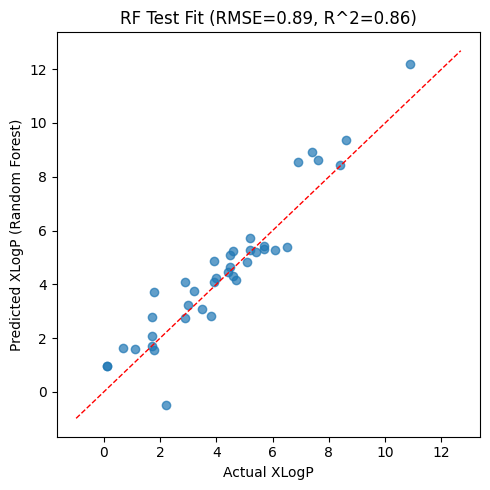

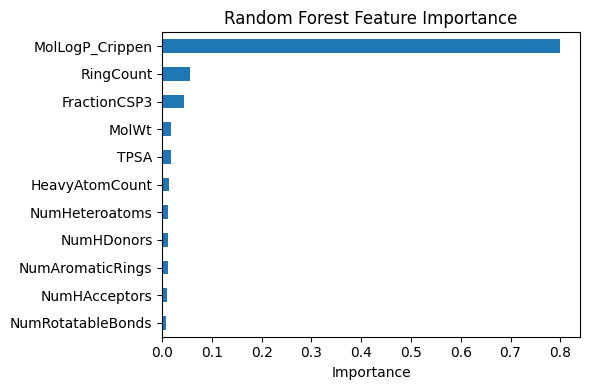

In [9]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, rf_test_preds, alpha=0.7)
lims = [min(y_test.min(), rf_test_preds.min()) - 0.5, max(y_test.max(), rf_test_preds.max()) + 0.5]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual XLogP")
plt.ylabel("Predicted XLogP (Random Forest)")
plt.title(f"RF Test Fit (RMSE={rf_rmse:.2f}, R^2={rf_r2:.2f})")
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)
plt.figure(figsize=(6,4))
importances.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 7. (Optional) PyTorch neural network for comparison\n\nIncluded for comparison only — with ~150 training rows this will very likely underperform or match the Random Forest, not beat it. Skip this section if you just want the RF model.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(SEED)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

class XLogPNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )
    def forward(self, x):
        return self.fc(x)

nn_model = XLogPNet(n_features=X_train_t.shape[1])
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

best_test_loss, best_state, patience, patience_counter = float("inf"), None, 40, 0

for epoch in range(1, 401):
    nn_model.train()
    pred = nn_model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    nn_model.eval()
    with torch.no_grad():
        test_loss = loss_fn(nn_model(X_test_t), y_test_t).item()

    if test_loss < best_test_loss:
        best_test_loss, best_state, patience_counter = test_loss, {k: v.clone() for k, v in nn_model.state_dict().items()}, 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

nn_model.load_state_dict(best_state)
nn_model.eval()
with torch.no_grad():
    nn_test_preds = nn_model(X_test_t).numpy().flatten()

nn_rmse = mean_squared_error(y_test, nn_test_preds) ** 0.5
nn_r2 = r2_score(y_test, nn_test_preds)
print(f"NN held-out test RMSE: {nn_rmse:.3f} | R^2: {nn_r2:.3f}")
print(f"(Compare to RF: RMSE={rf_rmse:.3f} | R^2={rf_r2:.3f})")


NN held-out test RMSE: 0.874 | R^2: 0.868
(Compare to RF: RMSE=0.887 | R^2=0.864)


## 8. Predict XLogP for unknown molecules\n\nEnter one or more SMILES strings below. Uses the Random Forest model (swap `rf` for `nn_model` + the torch prediction path if you prefer the NN).

In [11]:
unknown_smiles = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",          # example: aspirin - replace with your own SMILES
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",       # example: caffeine
]

def predict_xlogp_rf(smiles_list):
    results = []
    for smi in smiles_list:
        feats = get_features(smi)
        if feats is None:
            results.append({"SMILES": smi, "predicted_XLogP": None, "note": "Invalid SMILES - could not parse"})
            continue
        feats_scaled = scaler.transform([feats])
        pred = rf.predict(feats_scaled)[0]
        results.append({"SMILES": smi, "predicted_XLogP": round(float(pred), 3), "note": "Random Forest prediction"})
    return pd.DataFrame(results)

predictions_df = predict_xlogp_rf(unknown_smiles)
predictions_df


,SMILES,predicted_XLogP,note
0,CC(=O)OC1=CC=CC=C1C(=O)O,-0.341,Random Forest prediction
1,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,0.905,Random Forest prediction


### Applicability domain check\n\nFlags molecules whose descriptors fall outside your training set's range on any feature — predictions for these are lower-confidence extrapolations.

In [12]:
train_min = X_train.min(axis=0)
train_max = X_train.max(axis=0)

def in_domain(smiles):
    feats = get_features(smiles)
    if feats is None:
        return None
    feats = np.array(feats)
    return bool(((feats >= train_min) & (feats <= train_max)).all())

predictions_df["in_applicability_domain"] = predictions_df["SMILES"].apply(in_domain)
predictions_df


,SMILES,predicted_XLogP,note,in_applicability_domain
0,CC(=O)OC1=CC=CC=C1C(=O)O,-0.341,Random Forest prediction,False
1,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,0.905,Random Forest prediction,False


## 9. Save predictions

In [13]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
RUN_DIR = OUTPUT_DIR / f"run_{datetime.now().strftime('%Y%m%d-%H%M%S-%f')}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

out_path = RUN_DIR / "xlogp_predictions.csv"
predictions_df.to_csv(out_path, index=False)
print(f"Predictions saved to: {out_path}")

# Download it
from google.colab import files
files.download(str(out_path))


Predictions saved to: outputs/run_20260712-061752-379921/xlogp_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>